In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
churn = pd.read_csv('/content/drive/MyDrive/projects/customerchurn/Telco-Customer-Churn.csv')

In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(churn.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(churn.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
for i in churn.columns:
  print(f"Unique {i}'s count: {churn[i].nunique()}")
  print(f"{churn[i].unique()}\n\n")

Unique customerID's count: 7043
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']


Unique gender's count: 2
['Female' 'Male']


Unique SeniorCitizen's count: 2
[0 1]


Unique Partner's count: 2
['Yes' 'No']


Unique Dependents's count: 2
['No' 'Yes']


Unique tenure's count: 73
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


Unique PhoneService's count: 2
['No' 'Yes']


Unique MultipleLines's count: 3
['No phone service' 'No' 'Yes']


Unique InternetService's count: 3
['DSL' 'Fiber optic' 'No']


Unique OnlineSecurity's count: 3
['No' 'Yes' 'No internet service']


Unique OnlineBackup's count: 3
['Yes' 'No' 'No internet service']


Unique DeviceProtection's count: 3
['No' 'Yes' 'No internet service']


Unique TechSupport's count: 3
['No' 'Yes' 'No internet service']


Unique 

In [ ]:
churn.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# churn['TotalCharges'] = churn['TotalCharges'].astype(float)

In [ ]:
churn['TotalCharges'] = churn['TotalCharges'].replace(" ",np.nan)

In [ ]:
print(churn[churn['TotalCharges'].isna()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [ ]:
churn['TotalCharges'] = churn['TotalCharges'].fillna(0)

In [ ]:
print(churn[churn['TotalCharges'].isna()])

Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


In [ ]:
churn.query("TotalCharges == 0")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0,No


In [ ]:
churn['TotalCharges'] = churn['TotalCharges'].astype('float')

In [ ]:
no_internet_col = ['OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# for i in no_internet_col :
#   churn[i] = churn[i].apply(
#       lambda x : 'No' if x == 'No internet service' else x
#   )
churn[no_internet_col] = churn[no_internet_col].replace('No internet service','No')


In [ ]:
for i in no_internet_col:
  print(i)
  print(churn[i].unique())
  print()

OnlineSecurity
['No' 'Yes']

OnlineBackup
['Yes' 'No']

DeviceProtection
['No' 'Yes']

TechSupport
['No' 'Yes']

StreamingTV
['No' 'Yes']

StreamingMovies
['No' 'Yes']



In [ ]:
churn['MultipleLines'] = churn['MultipleLines'].replace('No phone service','No')

In [ ]:
churn.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
churn['tenure_groups'] = churn['tenure'].apply(
    lambda x : '0 month' if x == 0 else '(0-1)year' if x <= 12 else '(1-2)years' if x <= 24 else '(2-4)years' if x <= 48 else '4+years' )

In [ ]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_groups
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,(0-1)year
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,(2-4)years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,(0-1)year
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,(2-4)years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,(0-1)year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,(1-2)years
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,4+years
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,(0-1)year
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,(0-1)year


In [ ]:
mc = churn['MonthlyCharges']

In [ ]:
# print(mc.to_string())

In [ ]:
mc.sort_values(ascending = True)

,MonthlyCharges
3719,18.25
1529,18.40
6652,18.55
1156,18.70
6906,18.70
...,...
5127,118.35
3894,118.60
4804,118.60
2115,118.65


In [ ]:
mc = mc.reset_index()

In [ ]:
q2 = mc['MonthlyCharges'].median()

In [ ]:
q2

70.35

In [ ]:
q1_set = mc[mc['MonthlyCharges'] < 70.35]
q3_set = mc[mc['MonthlyCharges'] > 70.35]
q1 = q1_set.median()
q3 = q3_set.median()
print(q1,q2,q3)

index             3575.0
MonthlyCharges      35.5
dtype: float64 70.35 index             3472.0
MonthlyCharges      89.9
dtype: float64


In [ ]:
q1_set

,index,MonthlyCharges
0,0,29.85
1,1,56.95
2,2,53.85
3,3,42.30
7,7,29.75
...,...,...
7031,7031,60.00
7033,7033,69.50
7036,7036,60.65
7037,7037,21.15


In [ ]:
q1_set  = q1_set.drop(columns = ['index'])

In [ ]:
q1_set

,MonthlyCharges
0,29.85
1,56.95
2,53.85
3,42.30
7,29.75
...,...
7031,60.00
7033,69.50
7036,60.65
7037,21.15


In [ ]:
print(q1,q2,q3)

index             3575.0
MonthlyCharges      35.5
dtype: float64 70.35 index             3472.0
MonthlyCharges      89.9
dtype: float64


In [ ]:
churn['MonthlyChargesLevels'] = churn['MonthlyCharges'].apply(
    lambda x : 'low' if x <= 35.5 else 'Medium' if x <= 70.35 else 'High' if x <= 89.9 else 'VeryHigh'
)

In [ ]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_groups,MonthlyChargesLevels
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,(0-1)year,low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,(2-4)years,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,(0-1)year,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,(2-4)years,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,(0-1)year,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,(1-2)years,High
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,4+years,VeryHigh
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,(0-1)year,low
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,(0-1)year,High


In [ ]:
churn['customerID'] =  churn['customerID'].drop_duplicates()

In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   int64  
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   object 
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   object 
 10  OnlineBackup          7043 non-null   object 
 11  DeviceProtection      7043 non-null   object 
 12  TechSupport           7043 non-null   object 
 13  StreamingTV           7043 non-null   object 
 14  StreamingMovies       7043 non-null   object 
 15  Contract             

In [ ]:
churn[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
churn.duplicated().sum()

np.int64(0)

In [ ]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# churn.to_csv("cleaned_churn.csv")

In [ ]:
churn['Churn_encoded'] = churn['Churn'].map({'Yes' : 1, 'No' : 0})

In [ ]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_groups,MonthlyChargesLevels,Churn_encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,(0-1)year,low,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,(2-4)years,Medium,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,(0-1)year,Medium,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,(2-4)years,Medium,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,(0-1)year,High,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,No,(1-2)years,High,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,4+years,VeryHigh,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,(0-1)year,low,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,(0-1)year,High,1


In [ ]:
corr_with_churn = churn[['SeniorCitizen',
                      'tenure',
                      'MonthlyCharges',
                      'TotalCharges',
                      'Churn_encoded']].corr()

print(corr_with_churn['Churn_encoded'].sort_values(ascending=False))

Churn_encoded     1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_encoded, dtype: float64


Text(0.5, 1.0, 'Correlation with Churn')

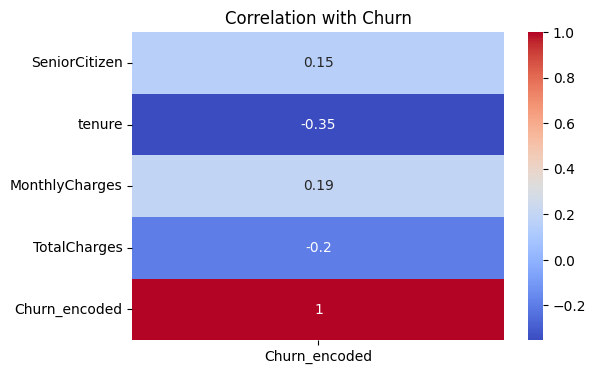

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_with_churn[['Churn_encoded']],
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with Churn')
# plt.show()

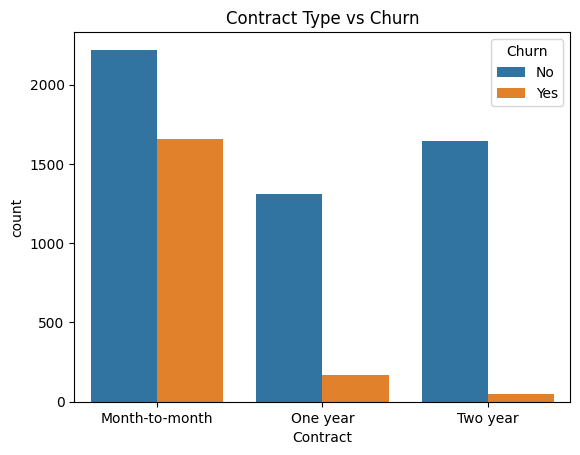

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=churn)
plt.title('Contract Type vs Churn')
plt.show()

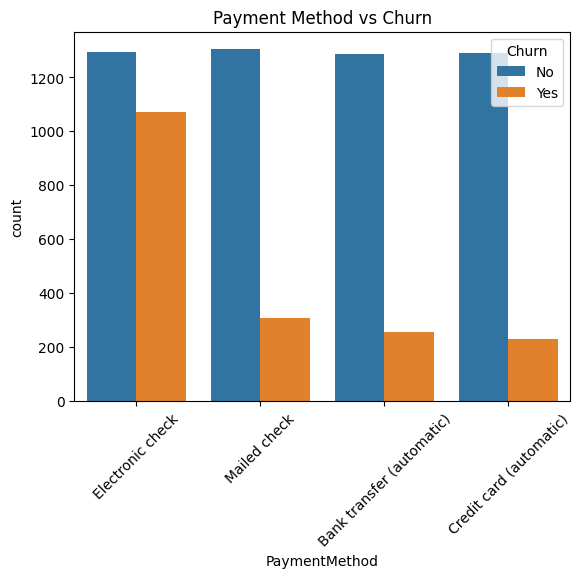

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=churn)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)
plt.show()
plt.show()

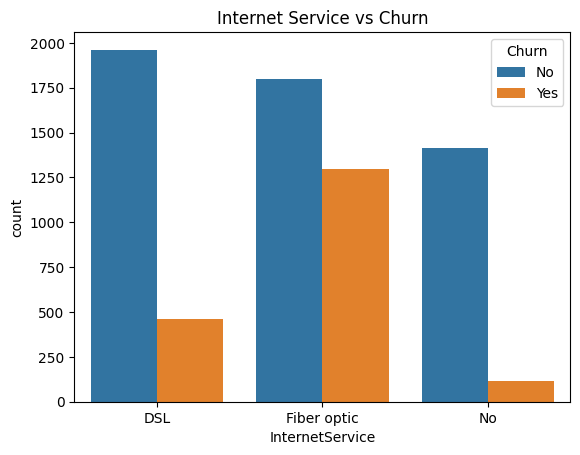

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=churn)
plt.title('Internet Service vs Churn')
plt.show()

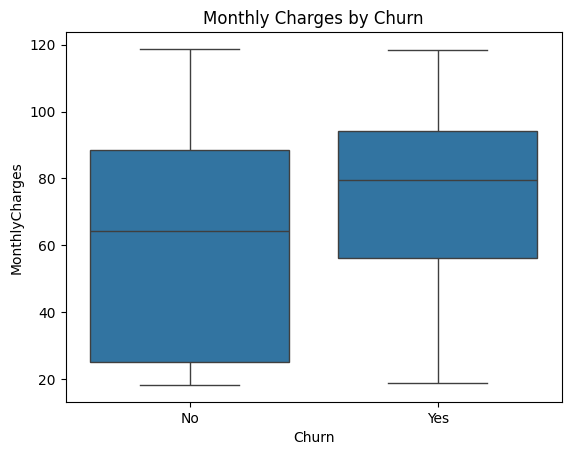

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn)
plt.title('Monthly Charges by Churn')
plt.show()

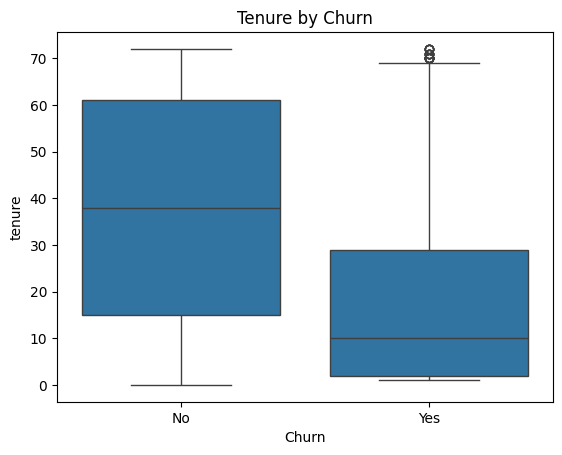

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=churn)
plt.title('Tenure by Churn')
plt.show()

In [ ]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_groups', 'MonthlyChargesLevels', 'Churn_encoded'],
      dtype='object')

In [ ]:
mappings = {
    'gender': {'Male': 0, 'Female': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'Churn': {'No': 0, 'Yes': 1}
}

for i, mapping in mappings.items():
    churn[i] = churn[i].map(mapping)

In [ ]:
churn[['gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling',
    'Churn']].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,1,0,0,1,0
1,0,0,0,1,0,0
2,0,0,0,1,1,1
3,0,0,0,0,0,0
4,1,0,0,1,1,1


In [ ]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

churn = pd.get_dummies(
    churn,
    columns=multi_cols,
    drop_first=True
)

In [ ]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,1,0,1,0,1,29.85,29.85,...,True,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,0,0,0,0,34,1,0,56.95,1889.50,...,False,True,False,False,False,True,False,False,False,True
2,3668-QPYBK,0,0,0,0,2,1,1,53.85,108.15,...,True,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,0,0,0,0,45,0,0,42.30,1840.75,...,False,True,True,False,False,True,False,False,False,False
4,9237-HQITU,1,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,0,1,1,24,1,1,84.80,1990.50,...,False,True,True,True,True,True,False,False,False,True
7039,2234-XADUH,1,0,1,1,72,1,1,103.20,7362.90,...,True,True,False,True,True,True,False,True,False,False
7040,4801-JZAZL,1,0,1,1,11,0,1,29.60,346.45,...,False,False,False,False,False,False,False,False,True,False
7041,8361-LTMKD,0,1,1,0,4,1,1,74.40,306.60,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   float64
 10  Churn                                  7043 non-null   int64  
 11  tenu

In [ ]:
bool_cols = churn.select_dtypes('bool').columns

churn[bool_cols] = churn[bool_cols].astype(int)

In [ ]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,1,0,1,0,1,29.85,29.85,...,1,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,0,0,0,0,34,1,0,56.95,1889.50,...,0,1,0,0,0,1,0,0,0,1
2,3668-QPYBK,0,0,0,0,2,1,1,53.85,108.15,...,1,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,0,0,0,0,45,0,0,42.30,1840.75,...,0,1,1,0,0,1,0,0,0,0
4,9237-HQITU,1,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,0,1,1,24,1,1,84.80,1990.50,...,0,1,1,1,1,1,0,0,0,1
7039,2234-XADUH,1,0,1,1,72,1,1,103.20,7362.90,...,1,1,0,1,1,1,0,1,0,0
7040,4801-JZAZL,1,0,1,1,11,0,1,29.60,346.45,...,0,0,0,0,0,0,0,0,1,0
7041,8361-LTMKD,0,1,1,0,4,1,1,74.40,306.60,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
churn.select_dtypes(include='object').columns

Index(['customerID', 'tenure_groups', 'MonthlyChargesLevels'], dtype='object')

In [ ]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'tenure_groups', 'MonthlyChargesLevels',
       'Churn_encoded', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
X = churn[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges','MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']]
y = churn['Churn_encoded']

In [ ]:
print(X.shape)
print(y.shape)

(7043, 23)
(7043,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5634, 23)
(1409, 23)


In [ ]:
X.isnull().sum().sum()

np.int64(0)

In [ ]:
y.isnull().sum()

np.int64(0)

In [ ]:
X.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,1,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8026969481902059


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7899219304471257
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
8                     TotalCharges    0.190922
4                           tenure    0.176124
7                   MonthlyCharges    0.175305
10     InternetService_Fiber optic    0.048193
21  PaymentMethod_Electronic check    0.039757
19               Contract_Two year    0.034181
0                           gender    0.028489
6                 PaperlessBilling    0.027497
12              OnlineSecurity_Yes    0.024076
2                          Partner    0.023039


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8005677785663591
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
10     InternetService_Fiber optic    0.205593
18               Contract_One year    0.194750
19               Contract_Two year    0.178141
11              InternetService_No    0.088233
21  PaymentMethod_Electronic check    0.063670
4                           tenure    0.054224
17             StreamingMovies_Yes    0.036616
6                 PaperlessBilling    0.026751
12              OnlineSecurity_Yes    0.024474
16                 StreamingTV_Yes    0.019423


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [80.27, 78.99, 80.06],
    'Precision (%)': [65, 63, 66],
    'Recall (%)': [56, 50, 52],
    'F1 Score (%)': [60, 56, 58]
})

comparison_df

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,80.27,65,56,60
1,Random Forest,78.99,63,50,56
2,XGBoost,80.06,66,52,58
